# P1b Stage 1-1: CasADi Symbolic Reconstruction of the 2D Point-Mass Cost-to-Go

**Scope** (per `P1b_roadmap.md`, advisor-confirmed): reconstruct the existing
2D point-mass cost-to-go map `J(z,h)` (`p1b_main.ipynb` Steps 1-6, computed
via Dijkstra) as a symbolic Bellman recursion in CasADi, then add a
fuel/energy constraint. This enables reverse-mode AD through the recursion,
needed for Stage 1-2 (defender-position minimax).

**Explicitly out of scope**: Step 7 onward in `p1b_main.ipynb` (fixed-wing
glider model, Step 9's 4D backward DP) -- deprioritized by the advisor in
favor of this 2D point-mass projection.

**This notebook does not modify `p1b_main.ipynb`.** It only reads its saved
outputs (`params.json`, `costmap_2d.json`) as a fixed numeric reference to
validate the symbolic reconstruction against.

**Convention**: same COMPUTE / PLOT cell split as `p1b_main.ipynb` --
COMPUTE cells save to `data/*.json`, PLOT cells load and visualize without
recomputing.

## Plan (see conversation log / roadmap for full reasoning)

- **Phase 0** (this section): setup, load the fixed numeric baseline to
  validate against.
- **Phase 1**: toy-scale grid (~20x20) -- validate the translation pattern
  (smooth occlusion, `z_tangent` via `rootfinder`, value-iteration Bellman
  backup as a repeated CasADi `Function`) and check `dJ/d(Z_SENSOR)` via AD
  vs. finite-difference *before* scaling up.
- **Phase 2**: full grid (200x200x37), validate symbolic `J_2D` against the
  numeric baseline loaded in Phase 0.
- **Phase 3**: fuel/energy constraint (form pending advisor confirmation).
- **Phase 4**: full-grid AD sanity check -- the actual deliverable enabling
  Stage 1-2.


In [1]:
# PHASE 0 -- SETUP
import os
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca

print('casadi', ca.__version__)

HERE = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
# p1b_main.ipynb's DATA_DIR convention: <repo>/p1b/data
DATA_DIR = os.path.join(os.getcwd(), 'data') if os.path.basename(os.getcwd()) == 'p1b' \
    else os.path.join(os.getcwd(), 'p1b', 'data')
assert os.path.isdir(DATA_DIR), f'DATA_DIR not found: {DATA_DIR}'
print('DATA_DIR =', DATA_DIR)


casadi 3.7.2
DATA_DIR = D:\git\git_research\glider_hybrid_control\p1b\data


In [2]:
# PHASE 0 -- Load existing params (reuse, do not redefine)
with open(os.path.join(DATA_DIR, 'params.json'), 'r') as f:
    params = json.load(f)

print(f"Z_SENSOR={params['Z_SENSOR']}, Z_GOAL={params['Z_GOAL']}, V_LAUNCH={params['V_LAUNCH']:.2f}")
print(f"N_Z={params['N_Z']}, N_H={params['N_H']}, D_GAMMA={params['D_GAMMA']}, "
      f"GAMMA_MIN_POINTMASS={params['GAMMA_MIN_POINTMASS']}")


Z_SENSOR=2000.0, Z_GOAL=2500.0, V_LAUNCH=21.00
N_Z=200, N_H=200, D_GAMMA=5.0, GAMMA_MIN_POINTMASS=-180.0


In [3]:
# PHASE 0 -- Load the fixed numeric reference to validate the symbolic
# reconstruction against (Step 6-1's Dijkstra J_2D, Z_SENSOR=2000). This is
# a frozen snapshot -- re-run p1b_main.ipynb's Step 6-1 explicitly and
# re-load here if the numeric baseline ever needs to be refreshed; this
# notebook does not do that automatically.
with open(os.path.join(DATA_DIR, 'costmap_2d.json'), 'r') as f:
    ref = json.load(f)

z_grid_ref = np.array(ref['z_grid'])
h_grid_ref = np.array(ref['h_grid'])
gamma_grid_ref = np.array(ref['gamma_grid'])
J_2D_ref = np.array(ref['J_2D'])
terrain_mask_ref = np.array(ref['terrain_mask_2d'], dtype=bool)
occlusion_mask_ref = np.array(ref['occlusion_mask_2d'], dtype=bool)
exclude_mask_ref = np.array(ref['exclude_mask_2d'], dtype=bool)
goal_cell_ref = ref['goal_cell']

NZ_ref, NH_ref = len(z_grid_ref), len(h_grid_ref)
n_finite_ref = np.isfinite(J_2D_ref[~exclude_mask_ref]).sum()
print(f'Reference J_2D: grid {NZ_ref}x{NH_ref}, gamma points={len(gamma_grid_ref)}, '
      f'goal_cell={goal_cell_ref}')
print(f'  finite (reachable, non-excluded) cells: {n_finite_ref}')
finite_vals = J_2D_ref[np.isfinite(J_2D_ref) & ~exclude_mask_ref]
print(f'  J_2D range (finite, non-excluded): [{finite_vals.min():.4f}, {finite_vals.max():.4f}]')


Reference J_2D: grid 200x200, gamma points=37, goal_cell=[181, 0]
  finite (reachable, non-excluded) cells: 22366
  J_2D range (finite, non-excluded): [0.0000, 10.7444]


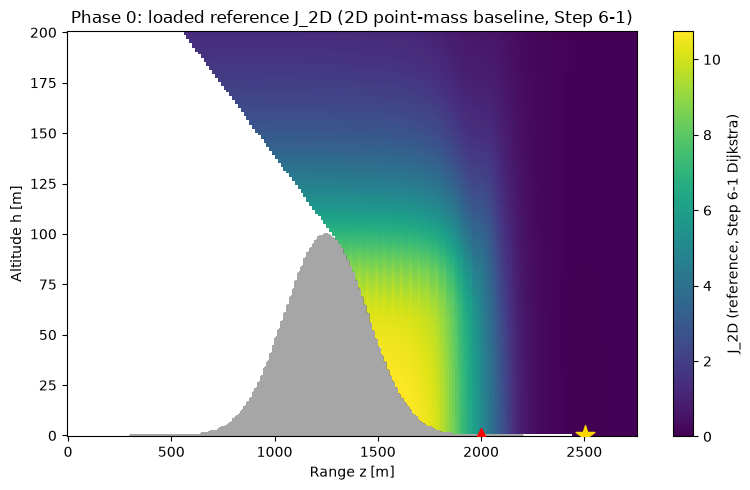

casadi_phase0_reference.png saved


In [4]:
# PHASE 0 PLOT -- sanity check: does the loaded reference look right?
fig, ax = plt.subplots(figsize=(8, 5))
Jb = np.where(np.isfinite(J_2D_ref) & ~exclude_mask_ref, J_2D_ref, np.nan)
im = ax.pcolormesh(z_grid_ref, h_grid_ref, Jb.T, cmap='viridis', shading='auto')
fig.colorbar(im, ax=ax, label='J_2D (reference, Step 6-1 Dijkstra)')
ax.contourf(z_grid_ref, h_grid_ref, terrain_mask_ref.T, levels=[0.5, 1.5], colors=['gray'], alpha=0.7)
iz_goal, ih_goal = goal_cell_ref
ax.scatter([z_grid_ref[iz_goal]], [h_grid_ref[ih_goal]], c='gold', marker='*', s=200, zorder=5, label='goal')
ax.scatter([params['Z_SENSOR']], [params['H_SENSOR']], c='red', marker='^', s=100, zorder=5, label='sensor')
ax.set_xlabel('Range z [m]'); ax.set_ylabel('Altitude h [m]')
ax.set_title('Phase 0: loaded reference J_2D (2D point-mass baseline, Step 6-1)')
# ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'casadi_phase0_reference.png'), dpi=120, bbox_inches='tight')
plt.show()
print('casadi_phase0_reference.png saved')


## Phase 1: Toy-Scale Validation (~20x20 grid)

Validate the translation pattern -- smooth occlusion, `z_tangent` via
`casadi.rootfinder`, value-iteration Bellman backup as a repeated CasADi
`Function` -- and check `dJ/d(Z_SENSOR)` via AD vs. finite-difference,
*before* scaling to the full 200x200x37 grid. Stage cost here is
Doppler+RCS only (matches `lambda_total_fn`'s `phase='glide'` path --
acoustic is powered-phase-only and Step 6-1's glide-phase map never calls
it).


In [5]:
# PHASE 1 -- toy grid
NZ_T, NH_T = 20, 20
D_GAMMA_T = 15.0   # deg, coarser than the real D_GAMMA=5.0

z_grid_t = np.linspace(0.0, params['Z_GOAL'] * 1.1, NZ_T)
h_grid_t = np.linspace(0.0, params['H_MAX_GRID'], NH_T)
gamma_grid_t = np.arange(params['GAMMA_MIN_POINTMASS'], 0.0 + 1e-9, D_GAMMA_T)
NG_T = len(gamma_grid_t)
print(f'toy grid: NZ={NZ_T}, NH={NH_T}, NG={NG_T}  ({NZ_T*NH_T*NG_T} (z,h,gamma) combos)')
print('gamma_grid_t (deg):', gamma_grid_t)


toy grid: NZ=20, NH=20, NG=13  (5200 (z,h,gamma) combos)
gamma_grid_t (deg): [-180. -165. -150. -135. -120. -105.  -90.  -75.  -60.  -45.  -30.  -15.
    0.]


In [6]:
# PHASE 1 -- z_tangent via casadi.rootfinder, validated against the numeric
# compute_LOS() tangent point already stored in the reference (terrain.json
# isn't loaded here, but costmap params + a fresh numeric compute_LOS gives
# the same answer -- reuse the notebook-independent formula directly).

def h_terrain_np(z, params):
    return params['H_RIDGE'] * np.exp(-0.5 * ((z - params['Z_RIDGE']) / params['SIGMA_TERRAIN'])**2)

def compute_LOS_numeric(z_sensor, h_sensor, params):
    zg = np.linspace(0.0, z_sensor, 2000, endpoint=False)
    hg = h_terrain_np(zg, params)
    sl = (hg - h_sensor) / (zg - z_sensor)
    st = hg * (-(zg - params['Z_RIDGE']) / params['SIGMA_TERRAIN']**2)
    diff = sl - st
    sc = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
    z_t = float((zg[sc[0]] + zg[sc[0]+1]) / 2) if len(sc) else float(zg[np.nanargmin(np.abs(diff))])
    h_t = float(h_terrain_np(z_t, params))
    slope = (h_t - h_sensor) / (z_t - z_sensor)
    return {'slope': float(slope), 'intercept': float(h_sensor - slope * z_sensor), 'z_tangent': z_t}

LOS_numeric_ref = compute_LOS_numeric(params['Z_SENSOR'], params['H_SENSOR'], params)
print('numeric z_tangent (reference):', LOS_numeric_ref['z_tangent'])

# --- symbolic version ---
def h_terrain_sym(z, p):
    return p['H_RIDGE'] * ca.exp(-0.5 * ((z - p['Z_RIDGE']) / p['SIGMA_TERRAIN'])**2)

z_sym = ca.MX.sym('z')
zsens_sym = ca.MX.sym('z_sensor')
h_sensor_c = float(params['H_SENSOR'])

ht_sym = h_terrain_sym(z_sym, params)
slope_line = (ht_sym - h_sensor_c) / (z_sym - zsens_sym)
dht_dz = ht_sym * (-(z_sym - params['Z_RIDGE']) / params['SIGMA_TERRAIN']**2)
residual = slope_line - dht_dz

g_fun = ca.Function('g_tangent', [z_sym, zsens_sym], [residual])
rf = ca.rootfinder('rf_tangent', 'newton', g_fun)

z0_guess = LOS_numeric_ref['z_tangent']   # good starting point, reused from numeric
z_tangent_sym_val = rf(z0_guess, params['Z_SENSOR'])
print('symbolic z_tangent (rootfinder, at Z_SENSOR=2000):', float(z_tangent_sym_val))
print('difference vs numeric:', float(z_tangent_sym_val) - LOS_numeric_ref['z_tangent'])


numeric z_tangent (reference): 1307.5
symbolic z_tangent (rootfinder, at Z_SENSOR=2000): 1307.7855614887362
difference vs numeric: 0.2855614887362208


In [7]:
# PHASE 1 -- smooth occlusion weight + stage cost (Doppler+RCS, glide phase
# only -- matches lambda_total_fn's phase='glide' path, no acoustic term).
OCC_WIDTH = 10.0   # meters, smoothing width -- tune later against the full baseline

def sigmoid(x):
    return 1.0 / (1.0 + ca.exp(-x))

def occlusion_weight_sym(z, h, z_tangent, los_slope, los_intercept, width=OCC_WIDTH):
    h_los = los_slope * z + los_intercept
    w_z = sigmoid((z_tangent - z) / width)
    w_h = sigmoid((h_los - h) / width)
    return w_z * w_h   # ~1 deep in the occlusion pocket, ~0 outside

def stage_lambda_sym(z, h, v, gamma_deg, z_sensor, h_sensor, los_slope, los_intercept, z_tangent, params):
    """Doppler + RCS, single sensor, smoothed occlusion. gamma_deg: action
    gamma_cmd in degrees (matches lambda_doppler/lambda_rcs's convention)."""
    dz = z_sensor - z
    dh = h_sensor - h
    r = ca.sqrt(dz**2 + dh**2)
    r_eff = ca.fmax(r, params['R_FLOOR'])

    gamma_rad = gamma_deg * ca.pi / 180.0
    vz = v * ca.cos(gamma_rad)
    vh = v * ca.sin(gamma_rad)
    los_z = dz / r_eff
    los_h = dh / r_eff
    v_r = vz * los_z + vh * los_h
    lam_dop = params['LAM_DOPPLER'] * v_r**2 / r_eff**4

    gamma_min = params['GAMMA_MIN']
    cos_term = ca.cos((gamma_deg - gamma_min) * ca.pi / 180.0)
    lam_rcs = params['LAM_RCS'] * params['SIGMA0'] * cos_term**2 / r_eff**4

    lam_raw = lam_dop + lam_rcs
    lam_raw = ca.fmax(lam_raw, params['LAM_FLOOR'])

    w = occlusion_weight_sym(z, h, z_tangent, los_slope, los_intercept)
    return lam_raw * (1.0 - w), w

# --- sanity check vs numeric lambda_doppler+lambda_rcs at a few sample points ---
def lambda_doppler_np(z, h, v, gamma_deg, z_s, h_s, params):
    dz, dh = z_s - z, h_s - h
    r = np.sqrt(dz**2 + dh**2)
    if r < 1e-6:
        return 0.0
    gr = np.radians(gamma_deg)
    vz, vh = v*np.cos(gr), v*np.sin(gr)
    r_eff = max(r, params['R_FLOOR'])
    v_r = vz*(dz/r) + vh*(dh/r)
    return params['LAM_DOPPLER'] * v_r**2 / r_eff**4

def lambda_rcs_np(z, h, gamma_deg, z_s, h_s, params):
    r = np.sqrt((z-z_s)**2 + (h-h_s)**2)
    r_eff = max(r, params['R_FLOOR'])
    cos_term = np.cos(np.radians(gamma_deg - params['GAMMA_MIN']))
    return params['LAM_RCS'] * params['SIGMA0'] * cos_term**2 / r_eff**4

test_pts = [(1800.0, 60.0, 21.0, -30.0), (2200.0, 20.0, 21.0, -60.0), (500.0, 50.0, 21.0, -10.0)]
z_t_num = LOS_numeric_ref['z_tangent']
los_slope_num = LOS_numeric_ref['slope']
los_int_num = LOS_numeric_ref['intercept']

zz, hh, vv, gg = ca.MX.sym('zz'), ca.MX.sym('hh'), ca.MX.sym('vv'), ca.MX.sym('gg')
lam_expr, w_expr = stage_lambda_sym(zz, hh, vv, gg, params['Z_SENSOR'], params['H_SENSOR'],
                                     los_slope_num, los_int_num, z_t_num, params)
stage_fun = ca.Function('stage_lambda', [zz, hh, vv, gg], [lam_expr, w_expr])

print(f'{"point":>28}  {"numeric lam":>14}  {"symbolic lam":>14}  {"occ weight":>10}')
for z_p, h_p, v_p, g_p in test_pts:
    lam_np = lambda_doppler_np(z_p, h_p, v_p, g_p, params['Z_SENSOR'], params['H_SENSOR'], params) \
           + lambda_rcs_np(z_p, h_p, g_p, params['Z_SENSOR'], params['H_SENSOR'], params)
    lam_np = max(lam_np, params['LAM_FLOOR'])
    lam_s, w_s = stage_fun(z_p, h_p, v_p, g_p)
    print(f'(z={z_p:6.0f},h={h_p:5.0f},v={v_p:4.0f},g={g_p:5.0f})  {lam_np:14.6e}  {float(lam_s):14.6e}  {float(w_s):10.4f}')


                       point     numeric lam    symbolic lam  occ weight
(z=  1800,h=   60,v=  21,g=  -30)    3.605997e-01    3.605997e-01      0.0000
(z=  2200,h=   20,v=  21,g=  -60)    2.997525e-01    2.997525e-01      0.0000
(z=   500,h=   50,v=  21,g=  -10)    5.000000e-04    6.985465e-11      1.0000


In [8]:
# PHASE 1 -- isolated test: casadi.interpolant with SYMBOLIC data (not baked
# in at construction), since J changes every value-iteration sweep and must
# stay part of the z_sensor-dependent symbolic graph. 'linear' gave garbage
# (grad all zero) above -- try 'bspline' with degree=1 (equivalent to linear
# interpolation for a bspline) instead, which is CasADi's documented way to
# get runtime/symbolic coefficients.
grid_x_test = np.linspace(0.0, 10.0, 5)
data_vals = np.array([0.0, 1.0, 4.0, 9.0, 16.0])   # x^2 at grid_x_test

LUT_bs = ca.interpolant('LUT_bs', 'bspline', [grid_x_test], 1, {'degree': [1]})
print('LUT_bs signature: n_in=', LUT_bs.n_in(), 'n_out=', LUT_bs.n_out())
print('  arg names:', [LUT_bs.name_in(i) for i in range(LUT_bs.n_in())])

data_test = ca.MX.sym('data_test', 5)
x_test = ca.MX.sym('x_test', 1)
y_test = LUT_bs(x_test, data_test)
f_test = ca.Function('f_test', [x_test, data_test], [y_test])

print('interp at x=2.5 (expect ~6.5 for linear):', float(f_test(2.5, data_vals)))
print('interp at x=0.0 (expect 0.0):', float(f_test(0.0, data_vals)))
print('interp at x=10.0 (expect 16.0):', float(f_test(10.0, data_vals)))

grad_test = ca.jacobian(y_test, data_test)
grad_fun = ca.Function('grad_fun', [x_test, data_test], [grad_test])
print('d(interp)/d(data) at x=2.5 (expect weight ~0.5 on idx2, ~0.5 on idx3):',
      np.array(grad_fun(2.5, data_vals)).ravel())


LUT_bs signature: n_in= 2 n_out= 1
  arg names: ['x', 'c']
interp at x=2.5 (expect ~6.5 for linear): 1.0
interp at x=0.0 (expect 0.0): 0.0
interp at x=10.0 (expect 16.0): 16.0
d(interp)/d(data) at x=2.5 (expect weight ~0.5 on idx2, ~0.5 on idx3): [0. 0. 0. 0. 0.]


**Finding**: `casadi.interpolant` with runtime/symbolic coefficients did not
behave as expected above (wrong interpolated values away from the grid
boundary, and zero gradient w.r.t. the data vector) -- likely a coefficient-
vs-value semantics mismatch for the bspline solver that needs more digging.
**Pivoting**: point-mass transition kinematics never reference `Z_SENSOR`
(only the stage cost does), so the landing position -- and therefore the
bilinear interpolation weights -- can be precomputed once in plain numpy,
outside the symbolic graph. "Interpolate J at the next state" then becomes
a plain matrix-vector product `W @ J`, which is exactly and trivially
differentiable, sidestepping the interpolant issue entirely.


In [9]:
# PHASE 1 -- precompute transitions + bilinear interpolation weight matrix
# (pure numpy, Z_SENSOR-independent: point-mass kinematics never reference
# the sensor -- only stage cost does). This sidesteps casadi.interpolant's
# runtime-coefficient quirks entirely: "interpolate J at next state" becomes
# a plain matrix-vector product W @ J, which is trivially differentiable.
V_PM = params['V_LAUNCH']
DT = params['DT_GLIDE']
N_SUB = int(round(params['DT_DP'] / params['DT_GLIDE']))

dz_t = z_grid_t[1] - z_grid_t[0]
dh_t = h_grid_t[1] - h_grid_t[0]

terrain_t = h_terrain_np(z_grid_t, params)   # (NZ_T,) terrain height at each z (h grid uses same z coords per row)


def bilinear_weights(z_q, h_q):
    """Return (iz0, ih0, wz, wh) for a query point, clipped to grid range."""
    zf = np.clip((z_q - z_grid_t[0]) / dz_t, 0.0, NZ_T - 1 - 1e-9)
    hf = np.clip((h_q - h_grid_t[0]) / dh_t, 0.0, NH_T - 1 - 1e-9)
    iz0 = int(np.floor(zf)); ih0 = int(np.floor(hf))
    wz = zf - iz0; wh = hf - ih0
    return iz0, ih0, wz, wh


n_cells = NZ_T * NH_T
n_trans = NZ_T * NH_T * NG_T
W = np.zeros((n_trans, n_cells))          # interpolation weight matrix
valid_mask = np.ones(n_trans, dtype=bool)  # False = terrain/ground violation -> force invalid

trans_idx = 0
for iz in range(NZ_T):
    for ih in range(NH_T):
        z0, h0 = z_grid_t[iz], h_grid_t[ih]
        for ig in range(NG_T):
            g_deg = gamma_grid_t[ig]
            g_rad = math.radians(g_deg)
            z, h = z0, h0
            ok = True
            for _ in range(N_SUB):
                z = z + V_PM * math.cos(g_rad) * DT
                h = max(h + V_PM * math.sin(g_rad) * DT, 0.0)
                if h < h_terrain_np(np.array([z]), params)[0] - 1e-6 or h < -1e-6:
                    ok = False
                    break
            if ok and (z_grid_t[0] <= z <= z_grid_t[-1]) and (h_grid_t[0] <= h <= h_grid_t[-1]):
                iz0, ih0, wz, wh = bilinear_weights(z, h)
                iz1, ih1 = min(iz0 + 1, NZ_T - 1), min(ih0 + 1, NH_T - 1)
                W[trans_idx, iz0 * NH_T + ih0] += (1 - wz) * (1 - wh)
                W[trans_idx, iz0 * NH_T + ih1] += (1 - wz) * wh
                W[trans_idx, iz1 * NH_T + ih0] += wz * (1 - wh)
                W[trans_idx, iz1 * NH_T + ih1] += wz * wh
            else:
                valid_mask[trans_idx] = False
            trans_idx += 1

print(f'transitions: {n_trans}, valid: {valid_mask.sum()}, invalid (terrain/out-of-grid): {(~valid_mask).sum()}')
W_ca = ca.DM(W)   # constant (Z_SENSOR-independent), reused every sweep


transitions: 5200, valid: 3914, invalid (terrain/out-of-grid): 1286


In [10]:
# PHASE 1 -- symbolic stage cost per action + one Bellman backup, using the
# W matrix from the previous cell instead of casadi.interpolant.
Z_flat_grid = np.repeat(z_grid_t, NH_T)   # (n_cells,), iz-outer/ih-inner -- matches W row slicing below
H_flat_grid = np.tile(h_grid_t, NZ_T)

# z_tangent, LOS slope/intercept as symbolic functions of z_sensor (reuse the
# rootfinder from the earlier cell; z_tangent_sym depends on zsens_sym).
z_tangent_sym = rf(z0_guess, zsens_sym)
h_tangent_sym = h_terrain_sym(z_tangent_sym, params)
los_slope_sym = (h_tangent_sym - h_sensor_c) / (z_tangent_sym - zsens_sym)
los_intercept_sym = h_sensor_c - los_slope_sym * zsens_sym

# Per-action stage cost vectors (length n_cells each), all depending on zsens_sym.
stage_cost_by_action = []
for ig in range(NG_T):
    g_deg = float(gamma_grid_t[ig])
    lam_a, w_a = stage_lambda_sym(Z_flat_grid, H_flat_grid, V_PM, g_deg,
                                   zsens_sym, h_sensor_c, los_slope_sym, los_intercept_sym,
                                   z_tangent_sym, params)
    # NOTE: single lambda eval at the stage's start point, not substepped like
    # the numeric c_lagged sweep -- a Phase-1 simplification, revisit in Phase 2.
    stage_pod_a = 1.0 - ca.exp(-lam_a * params['DT_DP'])
    stage_cost_a = stage_pod_a + params['W_TIME'] * params['DT_DP']
    stage_cost_by_action.append(stage_cost_a)

W_by_action = [ca.DM(W[ig::NG_T, :]) for ig in range(NG_T)]   # (n_cells, n_cells) each, Z_SENSOR-independent
valid_by_action = [valid_mask[ig::NG_T] for ig in range(NG_T)]

# Goal cell (nearest toy-grid index to Z_GOAL, H_GOAL)
iz_goal_t = int(np.argmin(np.abs(z_grid_t - params['Z_GOAL'])))
ih_goal_t = int(np.argmin(np.abs(h_grid_t - params['H_GOAL'])))
goal_flat_t = iz_goal_t * NH_T + ih_goal_t
print(f'toy goal cell: iz={iz_goal_t} (z={z_grid_t[iz_goal_t]:.1f}), ih={ih_goal_t} (h={h_grid_t[ih_goal_t]:.1f})')

LARGE = 50.0   # "unreachable" sentinel -- finite (not inf) so gradients stay well-defined
terrain_flat_t = (H_flat_grid < h_terrain_np(Z_flat_grid, params) - 1e-6)
print(f'toy terrain-excluded cells: {terrain_flat_t.sum()} / {n_cells}')

J0_np = np.full(n_cells, LARGE)
J0_np[goal_flat_t] = 0.0
J0_np[terrain_flat_t] = LARGE   # terrain overrides goal (consistent with numeric convention)
J0 = ca.DM(J0_np)


goal_indicator_np = np.zeros(n_cells)
goal_indicator_np[goal_flat_t] = 1.0
goal_indicator = ca.DM(goal_indicator_np)
not_goal = ca.DM(1.0 - goal_indicator_np)


def bellman_backup(J, zsens_sym_local):
    totals = []
    for ig in range(NG_T):
        J_next = W_by_action[ig] @ J          # (n_cells,) interpolated cost-to-go at each transition's landing point
        total = stage_cost_by_action[ig] + J_next
        # invalid (terrain/out-of-grid) transitions -> force unreachable
        inval = ~valid_by_action[ig]
        if inval.any():
            total = total + ca.DM(inval.astype(float)) * LARGE
        totals.append(total)
    J_best = totals[0]
    for t in totals[1:]:
        J_best = ca.fmin(J_best, t)
    # terrain override every sweep (matches numeric: terrain stays LARGE)
    J_best = ca.DM(1 - terrain_flat_t.astype(float)) * ca.fmin(J_best, LARGE) + ca.DM(terrain_flat_t.astype(float)) * LARGE
    # goal override every sweep -- BUG FIX: without this, the goal cell's J=0
    # gets overwritten by its own "backup" (cost to leave and come back),
    # destroying the anchor that everything else propagates from. The numeric
    # Dijkstra/4D-DP versions never had this bug because they explicitly
    # skip updating the goal cell in their sweep loops; this toy backup
    # updates every cell uniformly, so the goal must be re-pinned explicitly.
    J_best = not_goal * J_best + goal_indicator * 0.0
    return J_best


# --- test: one backup application ---
J1_test = bellman_backup(J0, params['Z_SENSOR'])
J1_fun_test = ca.Function('J1_fun_test', [zsens_sym], [J1_test])
J1_val = np.array(J1_fun_test(params['Z_SENSOR'])).ravel()
n_fin1 = (J1_val < LARGE).sum()
print('after 1 sweep: finite(<LARGE) cells:', n_fin1, '/', n_cells)
if n_fin1 > 0:
    print('J1 min/max (excluding LARGE):', J1_val[J1_val < LARGE].min(), J1_val[J1_val < LARGE].max())
else:
    # Expected: stage displacement (V_LAUNCH*DT_DP ~ 42m) is much smaller than
    # one toy grid cell (dz_t ~ 145m), so it takes several sweeps just to
    # cross ONE cell -- 0 finite after 1 sweep is not necessarily a bug, see
    # next cell (run many sweeps).
    print(f'  (expected at this resolution: stage step ~{V_PM*params["DT_DP"]:.0f}m vs grid cell ~{dz_t:.0f}m)')


toy goal cell: iz=17 (z=2460.5), ih=0 (h=0.0)
toy terrain-excluded cells: 46 / 400
after 1 sweep: finite(<LARGE) cells: 1 / 400
J1 min/max (excluding LARGE): 0.0 0.0


In [11]:
# PHASE 1 -- chain many sweeps symbolically, evaluate at Z_SENSOR=2000, and
# check progress. Stage displacement (~V_LAUNCH*DT_DP) is much smaller than
# one toy grid cell here, so this toy setup needs many more sweeps than the
# ~5 the full-resolution numeric 4D DP needed earlier this session.
N_SWEEPS = 150

J_sym = J0
for _ in range(N_SWEEPS):
    J_sym = bellman_backup(J_sym, zsens_sym)

J_final_fun = ca.Function('J_final_fun', [zsens_sym], [J_sym])
J_final_val = np.array(J_final_fun(params['Z_SENSOR'])).ravel()
n_fin_final = (J_final_val < LARGE).sum()
print(f'after {N_SWEEPS} sweeps: finite(<LARGE) cells: {n_fin_final} / {n_cells}')
if n_fin_final > 0:
    fin_vals = J_final_val[J_final_val < LARGE]
    print(f'J range (finite): [{fin_vals.min():.4f}, {fin_vals.max():.4f}]')

# quick per-sweep-count progress check (cheaper: re-evaluate at a few smaller N)
for n_check in [10, 30, 60, 100, 150]:
    Jc = J0
    for _ in range(n_check):
        Jc = bellman_backup(Jc, zsens_sym)
    Jc_fun = ca.Function('Jc_fun', [zsens_sym], [Jc])
    Jc_val = np.array(Jc_fun(params['Z_SENSOR'])).ravel()
    print(f'  N={n_check:4d}: finite cells = {(Jc_val < LARGE).sum()} / {n_cells}')


after 150 sweeps: finite(<LARGE) cells: 286 / 400
J range (finite): [0.0000, 10.6279]
  N=  10: finite cells = 167 / 400


  N=  30: finite cells = 286 / 400


  N=  60: finite cells = 286 / 400


  N= 100: finite cells = 286 / 400


  N= 150: finite cells = 286 / 400


cells finite in both: 217 / 400
diff (toy - ref): mean=0.2281, mean|diff|=0.3049, max|diff|=1.8725


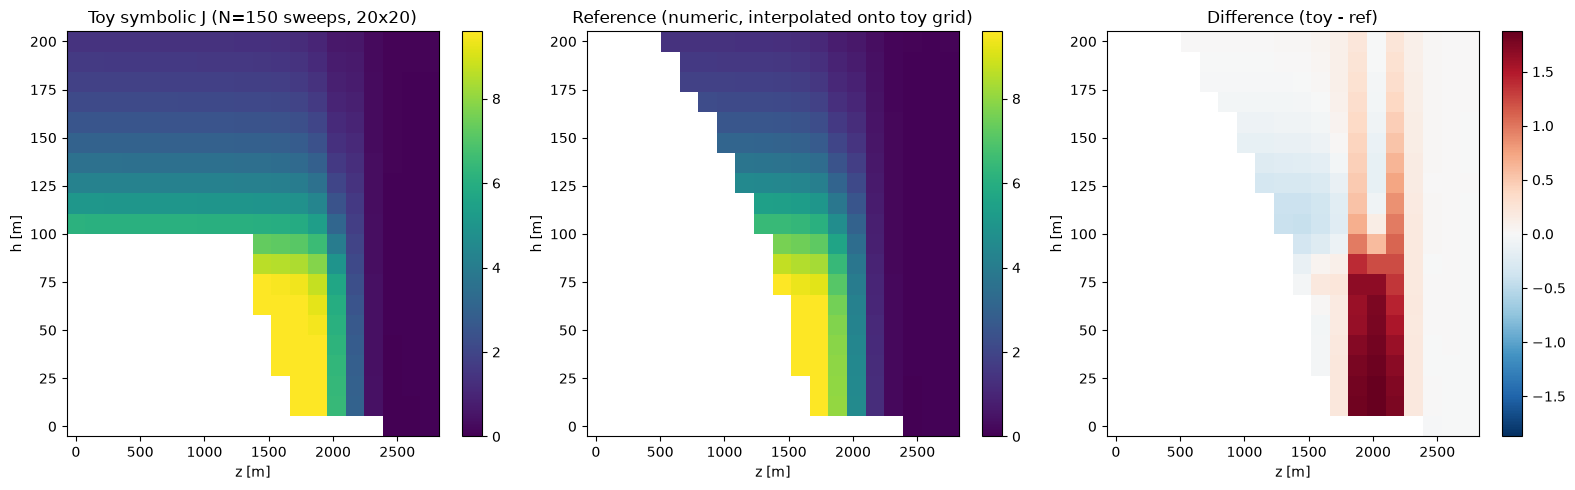

casadi_phase1_validation.png saved


In [12]:
# PHASE 1 -- validate toy symbolic J against the full-resolution numeric
# reference (interpolate the 200x200 reference onto the toy 20x20 points).
from scipy.interpolate import RegularGridInterpolator

Jref_for_interp = np.where(np.isfinite(J_2D_ref) & ~exclude_mask_ref, J_2D_ref, np.nan)
ref_interp = RegularGridInterpolator((z_grid_ref, h_grid_ref), Jref_for_interp,
                                      method='linear', bounds_error=False, fill_value=np.nan)
toy_pts = np.array([[z, h] for z in z_grid_t for h in h_grid_t])   # matches Z_flat_grid/H_flat_grid order
J_ref_on_toy = ref_interp(toy_pts)   # (n_cells,), NaN where reference is excluded/unreachable

J_toy = J_final_val.copy()
J_toy_masked = np.where(J_toy < LARGE, J_toy, np.nan)

both_finite = np.isfinite(J_ref_on_toy) & np.isfinite(J_toy_masked)
diff = J_toy_masked[both_finite] - J_ref_on_toy[both_finite]
print(f'cells finite in both: {both_finite.sum()} / {n_cells}')
print(f'diff (toy - ref): mean={diff.mean():.4f}, mean|diff|={np.abs(diff).mean():.4f}, max|diff|={np.abs(diff).max():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
Jt_grid = J_toy_masked.reshape(NZ_T, NH_T)
Jr_grid = J_ref_on_toy.reshape(NZ_T, NH_T)
vmax_c = np.nanpercentile(np.concatenate([Jt_grid.ravel(), Jr_grid.ravel()]), 95)

im0 = axes[0].pcolormesh(z_grid_t, h_grid_t, Jt_grid.T, cmap='viridis', vmin=0, vmax=vmax_c, shading='auto')
axes[0].set_title(f'Toy symbolic J (N={N_SWEEPS} sweeps, {NZ_T}x{NH_T})')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(z_grid_t, h_grid_t, Jr_grid.T, cmap='viridis', vmin=0, vmax=vmax_c, shading='auto')
axes[1].set_title('Reference (numeric, interpolated onto toy grid)')
fig.colorbar(im1, ax=axes[1])

diff_grid = np.full(n_cells, np.nan)
diff_grid[both_finite] = diff
im2 = axes[2].pcolormesh(z_grid_t, h_grid_t, diff_grid.reshape(NZ_T, NH_T).T, cmap='RdBu_r',
                          vmin=-np.abs(diff).max(), vmax=np.abs(diff).max(), shading='auto')
axes[2].set_title('Difference (toy - ref)')
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('z [m]'); ax.set_ylabel('h [m]')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'casadi_phase1_validation.png'), dpi=120, bbox_inches='tight')
plt.show()
print('casadi_phase1_validation.png saved')


In [13]:
# PHASE 1 -- the actual point of Stage 1-1: dJ/d(Z_SENSOR) via reverse-mode
# AD, checked against a central finite-difference on the SAME symbolic graph.
jac_expr = ca.jacobian(J_sym, zsens_sym)   # (n_cells, 1) -- reuses the N_SWEEPS-chained J_sym from the cell above
jac_fun = ca.Function('jac_fun', [zsens_sym], [jac_expr])
grad_ad = np.array(jac_fun(params['Z_SENSOR'])).ravel()

EPS = 1.0   # meters
Jp = np.array(J_final_fun(params['Z_SENSOR'] + EPS)).ravel()
Jm = np.array(J_final_fun(params['Z_SENSOR'] - EPS)).ravel()
grad_fd = (Jp - Jm) / (2 * EPS)

reachable_both = (J_final_val < LARGE)
err = grad_ad[reachable_both] - grad_fd[reachable_both]
print(f'reachable cells checked: {reachable_both.sum()}')
print(f'grad AD  range: [{grad_ad[reachable_both].min():.6f}, {grad_ad[reachable_both].max():.6f}]')
print(f'grad FD  range: [{grad_fd[reachable_both].min():.6f}, {grad_fd[reachable_both].max():.6f}]')
print(f'max |AD - FD|: {np.abs(err).max():.6e}')
print(f'mean|AD - FD|: {np.abs(err).mean():.6e}')

n_nonzero = (np.abs(grad_ad[reachable_both]) > 1e-8).sum()
print(f'cells with non-negligible dJ/d(Z_SENSOR): {n_nonzero} / {reachable_both.sum()} '
      f'(this is the whole point -- a hard-boolean occlusion would give ~0 almost everywhere)')


reachable cells checked: 286
grad AD  range: [-0.078672, 0.032773]
grad FD  range: [-0.078667, 0.032770]
max |AD - FD|: 1.191100e-04
mean|AD - FD|: 8.560477e-06
cells with non-negligible dJ/d(Z_SENSOR): 285 / 286 (this is the whole point -- a hard-boolean occlusion would give ~0 almost everywhere)


## Stage 1-1 Task 3: Fuel/Energy Constraint -- Two-Option Prototype

The point-mass baseline has no thrust/drag decision variable -- speed is
fixed (`V_LAUNCH`) in both the powered and glide phases -- so a classical
energy-balance fuel model isn't directly expressible (see the roadmap's
Stage 1-1 Task 3 discussion). Rather than guess which of the two flagged
options the advisor intends, this section implements **both as lightweight
prototypes** over the real 20 switching candidates, to make the difference
concrete before committing to one.

- **Option A (range/duration cap)**: fuel consumed proportional to total
  powered-phase distance, `d = sqrt(z_sw^2 + h_sw^2)`. A budget caps how far
  from launch a switching point can be, regardless of climb angle.
- **Option B (specific-energy proxy)**: fuel consumed proportional to
  mechanical work done against gravity to reach the switching altitude,
  `g * h_sw` (the `v^2/2` term is a constant here since `v=V_LAUNCH` always,
  so it drops out of any *comparison* between candidates). A budget caps how
  *high* a switching point can be, regardless of horizontal distance.

These are **not interchangeable** -- shown below, they rank the same 19
candidates in exactly opposite order.


In [14]:
# STAGE 1-1 TASK 3 -- fuel/energy: Option A (distance) vs Option B (specific
# energy) over the real switching candidates (terrain.json, same as Step 6-2).
with open(os.path.join(DATA_DIR, 'terrain.json'), 'r') as f:
    terrain_fuel = json.load(f)
switching_candidates_fuel = [c for c in terrain_fuel['switching_candidates'] if c[0] > 0.0]

fuel_rows = []
for z_sw, h_sw in switching_candidates_fuel:
    dist_a = math.sqrt(z_sw**2 + h_sw**2)                 # Option A: powered-phase range
    energy_b = params['G'] * h_sw                          # Option B: g*h_sw (v^2/2 term constant, drops out of ranking)
    fuel_rows.append({'z_sw': z_sw, 'h_sw': h_sw, 'dist_A': dist_a, 'energy_B': energy_b})

order_a = sorted(range(len(fuel_rows)), key=lambda i: fuel_rows[i]['dist_A'])
order_b = sorted(range(len(fuel_rows)), key=lambda i: fuel_rows[i]['energy_B'])
rank_a = {idx: pos for pos, idx in enumerate(order_a)}
rank_b = {idx: pos for pos, idx in enumerate(order_b)}

print(f'{"z_sw":>8} {"h_sw":>8} {"dist_A":>10} {"energy_B":>10} {"rank_A":>7} {"rank_B":>7}')
for i, r in enumerate(fuel_rows):
    print(f"{r['z_sw']:8.1f} {r['h_sw']:8.1f} {r['dist_A']:10.1f} {r['energy_B']:10.1f} {rank_a[i]:7d} {rank_b[i]:7d}")

rank_sum_const = all(rank_a[i] + rank_b[i] == len(fuel_rows) - 1 for i in range(len(fuel_rows)))
print(f'\\nrank_A + rank_B constant across all candidates (exactly reversed order)? {rank_sum_const}')
print('cheapest under Option A (closest to launch):', fuel_rows[order_a[0]])
print('cheapest under Option B (lowest altitude):  ', fuel_rows[order_b[0]])
print('these are DIFFERENT candidates -- the two fuel models disagree on what \"cheap\" means.')


    z_sw     h_sw     dist_A   energy_B  rank_A  rank_B
    65.8    268.0      276.0     2629.1       0      18
   131.6    258.9      290.4     2539.7       1      17
   197.4    249.8      318.3     2450.2       2      16
   263.2    240.7      356.6     2360.8       3      15
   328.9    231.5      402.3     2271.4       4      14
   394.7    222.4      453.1     2182.0       5      13
   460.5    213.3      507.5     2092.5       6      12
   526.3    204.2      564.5     2003.1       7      11
   592.1    195.1      623.4     1913.7       8      10
   657.9    186.0      683.7     1824.3       9       9
   723.7    176.8      745.0     1734.8      10       8
   789.5    167.7      807.1     1645.4      11       7
   855.3    158.6      869.8     1556.0      12       6
   921.1    149.5      933.1     1466.6      13       5
   986.8    140.4      996.8     1377.1      14       4
  1052.6    131.3     1060.8     1287.7      15       3
  1118.4    122.1     1125.1     1198.3      16 

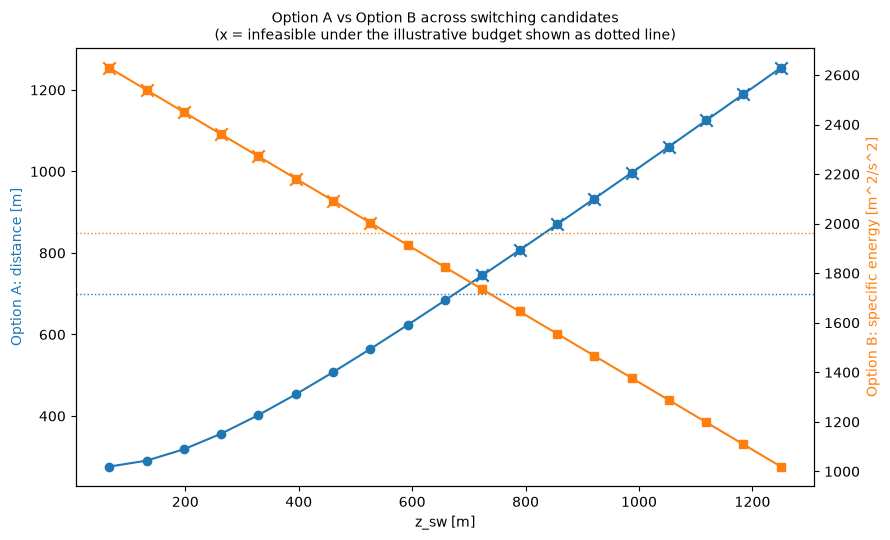

casadi_fuel_options.png saved
Option A excludes candidates with z_sw > ~658m (far from launch)
Option B excludes candidates with z_sw < ~592m (steep/high climb)
-> opposite ends of the candidate list get excluded depending on which model is chosen.


In [15]:
# STAGE 1-1 TASK 3 PLOT -- Option A vs Option B across switching candidates,
# plus an illustrative budget cutoff for each (values chosen only to
# demonstrate the effect -- not calibrated to a real fuel capacity).
z_sw_arr = np.array([r['z_sw'] for r in fuel_rows])
dist_a_arr = np.array([r['dist_A'] for r in fuel_rows])
energy_b_arr = np.array([r['energy_B'] for r in fuel_rows])

BUDGET_A = 700.0    # meters -- illustrative
BUDGET_B = params['G'] * 200.0   # illustrative: cap at h_sw=200m equivalent

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(z_sw_arr, dist_a_arr, 'o-', color='C0', label='Option A: powered-phase distance')
ax.axhline(BUDGET_A, color='C0', ls=':', lw=1)
ax.set_xlabel('z_sw [m]'); ax.set_ylabel('Option A: distance [m]', color='C0')

ax2 = ax.twinx()
ax2.plot(z_sw_arr, energy_b_arr, 's-', color='C1', label='Option B: g*h_sw')
ax2.axhline(BUDGET_B, color='C1', ls=':', lw=1)
ax2.set_ylabel('Option B: specific energy [m^2/s^2]', color='C1')

infeasible_a = dist_a_arr > BUDGET_A
infeasible_b = energy_b_arr > BUDGET_B
ax.scatter(z_sw_arr[infeasible_a], dist_a_arr[infeasible_a], marker='x', c='C0', s=80, zorder=5)
ax2.scatter(z_sw_arr[infeasible_b], energy_b_arr[infeasible_b], marker='x', c='C1', s=80, zorder=5)

ax.set_title('Option A vs Option B across switching candidates\n'
             '(x = infeasible under the illustrative budget shown as dotted line)', fontsize=10)
# ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'casadi_fuel_options.png'), dpi=120, bbox_inches='tight')
plt.show()
print('casadi_fuel_options.png saved')
print(f'Option A excludes candidates with z_sw > ~{z_sw_arr[~infeasible_a].max():.0f}m (far from launch)')
print(f'Option B excludes candidates with z_sw < ~{z_sw_arr[~infeasible_b].min():.0f}m (steep/high climb)')
print('-> opposite ends of the candidate list get excluded depending on which model is chosen.')


## Phase 1.5: Fixed-Wing Toy Grid (4D state)

Same validation goal as Phase 1, now with the real target model: state
`(z,h,v,γ)`, real `glider_dynamics` (RK4), projected to 2D via `min_{v,γ}`.
Reuses Phase 1's `stage_lambda_sym`, `occlusion_weight_sym`, the
`z_tangent` rootfinder, and the weight-matrix-instead-of-interpolant
pattern unchanged -- only the *transition* computation and grid
dimensionality are new (transitions stay `Z_SENSOR`-independent, so they
can still be precomputed in plain numpy).

In [16]:
# PHASE 1.5 -- load the fixed-wing numeric reference + toy 4D grid
d4 = np.load(os.path.join(DATA_DIR, 'p1b_4d_dp_results.npz'))
J_4D_ref = d4['J_4D']
z_grid_4ref = d4['z_grid']; h_grid_4ref = d4['h_grid']
v_grid_4ref = d4['v_grid']; g_grid_4ref = d4['gamma_grid']; a_grid_4ref = d4['gamma_cmd_grid']
print('reference J_4D shape:', J_4D_ref.shape)
J_2D_4ref = np.nanmin(np.where(np.isfinite(J_4D_ref), J_4D_ref, np.nan), axis=(2, 3))
fin4 = np.isfinite(J_2D_4ref)
print(f'reference J_2D_4d: finite={fin4.sum()}, range=[{J_2D_4ref[fin4].min():.4f}, {J_2D_4ref[fin4].max():.4f}]')

# toy 4D grid -- small per-dimension counts (4D grows fast: NZxNHxNVxNG states)
NZ_T2, NH_T2, NV_T2, NG_T2, NA_T2 = 22, 12, 3, 7, 5
z_grid_t2 = np.linspace(0.0, params['Z_GOAL'] * 1.1, NZ_T2)
h_grid_t2 = np.linspace(0.0, 300.0, NH_T2)             # matches p1b_4d_dp.py's H_MAX_GRID=300, not the notebook's 200
v_grid_t2 = np.array([14.0, 30.0, 100.0])               # subset of the real v_grid=[14,30,55,100]
g_grid_t2 = np.linspace(-90.0, 90.0, NG_T2)             # state gamma, climb-angle-extended (matches p1b_4d_dp.py)
a_grid_t2 = np.linspace(-90.0, 0.0, NA_T2)              # action gamma_cmd, glide-only
print(f'toy 4D grid: {NZ_T2}x{NH_T2}x{NV_T2}x{NG_T2} states, {NA_T2} actions '
      f'= {NZ_T2*NH_T2*NV_T2*NG_T2} states, {NZ_T2*NH_T2*NV_T2*NG_T2*NA_T2} transitions')


def required_CL_np(v, gamma, gamma_cmd, params):
    v_safe = max(v, 1e-3)
    desired_dgamma = (gamma_cmd - gamma) / params['TAU_CONTROL']
    L_req = params['M'] * v_safe * desired_dgamma + params['M'] * params['G'] * math.cos(gamma)
    CL_req = L_req / (0.5 * params['RHO'] * v_safe**2 * params['S'])
    return float(np.clip(CL_req, 0.0, params['CL_MAX']))


def glider_dynamics_np(state, gamma_cmd_rad, params):
    """Numpy port of p1b_main.ipynb Step 4 / p1b_4d_dp.py's glider_dynamics
    (RK4, Cartesian velocity). Transition-only use -- Z_SENSOR-independent,
    so this stays plain numpy (never enters the symbolic graph), matching
    the weight-matrix pattern from Phase 1."""
    def deriv(s):
        z, h, vz, vh = s
        v = math.hypot(vz, vh); v_safe = max(v, 1e-6)
        gamma = math.atan2(vh, vz)
        CL = required_CL_np(v, gamma, gamma_cmd_rad, params)
        L = 0.5 * params['RHO'] * v**2 * CL * params['S']
        D = 0.5 * params['RHO'] * v**2 * params['CD'] * params['S']
        az = (-D * vz - L * vh) / v_safe / params['M']
        ah = (-D * vh + L * vz) / v_safe / params['M'] - params['G']
        return np.array([vz, vh, az, ah])
    dt = params['DT_GLIDE']
    z0, h0, v0, g0 = state
    s = np.array([z0, h0, v0 * math.cos(g0), v0 * math.sin(g0)])
    k1 = deriv(s); k2 = deriv(s + 0.5*dt*k1); k3 = deriv(s + 0.5*dt*k2); k4 = deriv(s + dt*k3)
    s2 = s + dt * (k1 + 2*k2 + 2*k3 + k4) / 6
    z2, h2, vz2, vh2 = s2
    return (float(z2), float(max(h2, 0.0)), float(math.hypot(vz2, vh2)), float(math.atan2(vh2, vz2)))


reference J_4D shape: (100, 100, 4, 37)
reference J_2D_4d: finite=5725, range=[0.0000, 2.8468]
toy 4D grid: 22x12x3x7 states, 5 actions = 5544 states, 27720 transitions


C:\Users\jeffe\AppData\Local\Temp\ipykernel_19776\1050220798.py:7: RuntimeWarning: All-NaN slice encountered
  J_2D_4ref = np.nanmin(np.where(np.isfinite(J_4D_ref), J_4D_ref, np.nan), axis=(2, 3))


In [17]:
# PHASE 1.5 -- precompute 4D transitions + quad-linear interpolation weight
# matrix (numpy, Z_SENSOR-independent -- same reasoning as Phase 1's 2D
# bilinear weights, generalized to 4 dims / 16 corners per transition).
import time
dz_t2 = z_grid_t2[1] - z_grid_t2[0]
dh_t2 = h_grid_t2[1] - h_grid_t2[0]
dv_t2 = None  # v_grid_t2 is NOT uniformly spaced ([14,30,100]) -- handle separately
dg_t2 = g_grid_t2[1] - g_grid_t2[0]


def grid_index_frac(val, grid):
    """Fractional index into a (possibly non-uniform) 1D grid, clipped to range."""
    val = min(max(val, grid[0]), grid[-1])
    idx = np.searchsorted(grid, val) - 1
    idx = int(np.clip(idx, 0, len(grid) - 2))
    frac = (val - grid[idx]) / (grid[idx + 1] - grid[idx])
    return idx, frac


n_cells4 = NZ_T2 * NH_T2 * NV_T2 * NG_T2
n_trans4 = n_cells4 * NA_T2


def flat4(iz, ih, iv, ig):
    return ((iz * NH_T2 + ih) * NV_T2 + iv) * NG_T2 + ig


N_SUB2 = int(round(params['DT_DP'] / params['DT_GLIDE']))
W4 = np.zeros((n_trans4, n_cells4), dtype=np.float32)
valid4 = np.ones(n_trans4, dtype=bool)

t0 = time.time()
trans_idx = 0
for iz in range(NZ_T2):
    for ih in range(NH_T2):
        for iv in range(NV_T2):
            for ig in range(NG_T2):
                z0, h0, v0, g0d = z_grid_t2[iz], h_grid_t2[ih], v_grid_t2[iv], g_grid_t2[ig]
                g0r = math.radians(g0d)
                for ia in range(NA_T2):
                    a_deg = a_grid_t2[ia]
                    a_rad = math.radians(a_deg)
                    state = (z0, h0, v0, g0r)
                    ok = True
                    for _ in range(N_SUB2):
                        state = glider_dynamics_np(state, a_rad, params)
                        zk, hk, vk, gk = state
                        if hk < h_terrain_np(np.array([zk]), params)[0] - 1e-6 or vk < 0.5 * params['V_STALL']:
                            ok = False
                            break
                    if ok:
                        zk, hk, vk, gk = state
                        gk_deg = math.degrees(gk)
                        in_range = (z_grid_t2[0] <= zk <= z_grid_t2[-1]) and (h_grid_t2[0] <= hk <= h_grid_t2[-1]) \
                            and (v_grid_t2[0] <= vk <= v_grid_t2[-1]) and (g_grid_t2[0] <= gk_deg <= g_grid_t2[-1])
                        if in_range:
                            iz0, wz = grid_index_frac(zk, z_grid_t2)
                            ih0, wh = grid_index_frac(hk, h_grid_t2)
                            iv0, wv = grid_index_frac(vk, v_grid_t2)
                            ig0, wg = grid_index_frac(gk_deg, g_grid_t2)
                            for dz_ in (0, 1):
                                for dh_ in (0, 1):
                                    for dv_ in (0, 1):
                                        for dg_ in (0, 1):
                                            wgt = (wz if dz_ else 1-wz) * (wh if dh_ else 1-wh) * \
                                                  (wv if dv_ else 1-wv) * (wg if dg_ else 1-wg)
                                            if wgt > 0:
                                                col = flat4(iz0+dz_, ih0+dh_, iv0+dv_, ig0+dg_)
                                                W4[trans_idx, col] += wgt
                        else:
                            valid4[trans_idx] = False
                    else:
                        valid4[trans_idx] = False
                    trans_idx += 1

print(f'{time.time()-t0:.1f}s: transitions={n_trans4}, valid={valid4.sum()}, invalid={(~valid4).sum()}')


3.2s: transitions=27720, valid=15763, invalid=11957


In [18]:
# PHASE 1.5 -- symbolic stage cost (4D, reuses stage_lambda_sym from Phase 1
# unchanged -- it already takes v as a parameter) + goal/occlusion-domain
# handling + Bellman backup, all generalized from the Phase 1 point-mass
# toy pattern to the 4D fixed-wing grid.
ZZ4, HH4, VV4, GG4 = np.meshgrid(z_grid_t2, h_grid_t2, v_grid_t2, g_grid_t2, indexing='ij')
Z_flat4 = ZZ4.ravel(); H_flat4 = HH4.ravel(); V_flat4 = VV4.ravel(); G_flat4 = GG4.ravel()

IZ4, IH4, _, _ = np.meshgrid(np.arange(NZ_T2), np.arange(NH_T2), np.arange(NV_T2), np.arange(NG_T2), indexing='ij')
IZ_flat4 = IZ4.ravel(); IH_flat4 = IH4.ravel()

# Goal condition matches the p1b_4d_dp.py fix: actually landing (h ~ H_GOAL)
# at or past the target range (z >= Z_GOAL) -- not just crossing Z_GOAL at
# any altitude. Forward-only action set (a_grid_t2 in [-90,0]) means z is
# monotonic non-decreasing, so this is well-posed without backward flight.
iz_goal_t2 = int(np.searchsorted(z_grid_t2, params['Z_GOAL']))
ih_goal_t2 = int(np.argmin(np.abs(h_grid_t2 - params['H_GOAL'])))
goal_mask4 = (IZ_flat4 >= iz_goal_t2) & (IH_flat4 == ih_goal_t2)
print(f'toy4 goal: iz>={iz_goal_t2} (z={z_grid_t2[iz_goal_t2]:.1f}), ih=={ih_goal_t2} (h={h_grid_t2[ih_goal_t2]:.1f}), '
      f'{goal_mask4.sum()} cells (all v,gamma at that position)')

terrain_flat4 = (H_flat4 < h_terrain_np(Z_flat4, params) - 1e-6)
print(f'toy4 terrain-excluded: {terrain_flat4.sum()} / {n_cells4}')

# z_tangent / LOS symbolic (reuse from Phase 1 -- already a function of zsens_sym)
LARGE4 = 50.0
OCC_PENALTY = 50.0   # steep smooth penalty keeping the glide-phase domain out of
                      # the occlusion pocket -- Phase 1 only zeroed detection cost
                      # there and never added this; without it the glide map can
                      # leak into the pocket exactly like the bug fixed in
                      # p1b_4d_dp.py last session. Added here, and should be
                      # back-ported to Phase 1 for consistency.

stage_cost_by_action4 = []
for ia in range(NA_T2):
    a_deg = float(a_grid_t2[ia])
    lam_a, w_a = stage_lambda_sym(Z_flat4, H_flat4, V_flat4, a_deg,
                                   zsens_sym, h_sensor_c, los_slope_sym, los_intercept_sym,
                                   z_tangent_sym, params)
    stage_pod_a = 1.0 - ca.exp(-lam_a * params['DT_DP'])
    stage_cost_a = stage_pod_a + params['W_TIME'] * params['DT_DP'] + OCC_PENALTY * w_a
    stage_cost_by_action4.append(stage_cost_a)

W_by_action4 = [ca.DM(W4[ia::NA_T2, :].astype(np.float64)) for ia in range(NA_T2)]
valid_by_action4 = [valid4[ia::NA_T2] for ia in range(NA_T2)]

J0_np4 = np.full(n_cells4, LARGE4)
J0_np4[goal_mask4] = 0.0
J0_np4[terrain_flat4] = LARGE4
J0_4 = ca.DM(J0_np4)

goal_ind4 = ca.DM(goal_mask4.astype(float))
not_goal4 = ca.DM(1.0 - goal_mask4.astype(float))
terrain_ind4 = ca.DM(terrain_flat4.astype(float))
not_terrain4 = ca.DM(1.0 - terrain_flat4.astype(float))


def bellman_backup4(J, zsens_sym_local):
    totals = []
    for ia in range(NA_T2):
        J_next = W_by_action4[ia] @ J
        total = stage_cost_by_action4[ia] + J_next
        inval = ~valid_by_action4[ia]
        if inval.any():
            total = total + ca.DM(inval.astype(float)) * LARGE4
        totals.append(total)
    J_best = totals[0]
    for t in totals[1:]:
        J_best = ca.fmin(J_best, t)
    J_best = not_terrain4 * ca.fmin(J_best, LARGE4) + terrain_ind4 * LARGE4
    J_best = not_goal4 * J_best + goal_ind4 * 0.0
    return J_best


# --- test: one backup ---
J1_4 = bellman_backup4(J0_4, params['Z_SENSOR'])
J1_4_fun = ca.Function('J1_4_fun', [zsens_sym], [J1_4])
J1_4_val = np.array(J1_4_fun(params['Z_SENSOR'])).ravel()
print('after 1 sweep: finite cells:', (J1_4_val < LARGE4).sum(), '/', n_cells4)


toy4 goal: iz>=20 (z=2619.0), ih==0 (h=0.0), 42 cells (all v,gamma at that position)
toy4 terrain-excluded: 609 / 5544


after 1 sweep: finite cells: 148 / 5544


mapaccum graph built in 0.2s


evaluated in 74.6s
after 300 sweeps: finite cells: 2312 / 5544


  N=  10: finite cells = 2044 / 5544, finite max = 49.9993
  N=  30: finite cells = 2262 / 5544, finite max = 49.9826
  N=  60: finite cells = 2310 / 5544, finite max = 49.9979
  N= 120: finite cells = 2312 / 5544, finite max = 49.9928
  N= 180: finite cells = 2312 / 5544, finite max = 49.9928
  N= 240: finite cells = 2312 / 5544, finite max = 49.9928
  N= 300: finite cells = 2312 / 5544, finite max = 49.9928
toy J_2D range (finite): [0.0000, 45.6374]
cells finite in both: 136 / 264
diff (toy - ref): mean=7.2463, mean|diff|=7.2463, max|diff|=35.7310


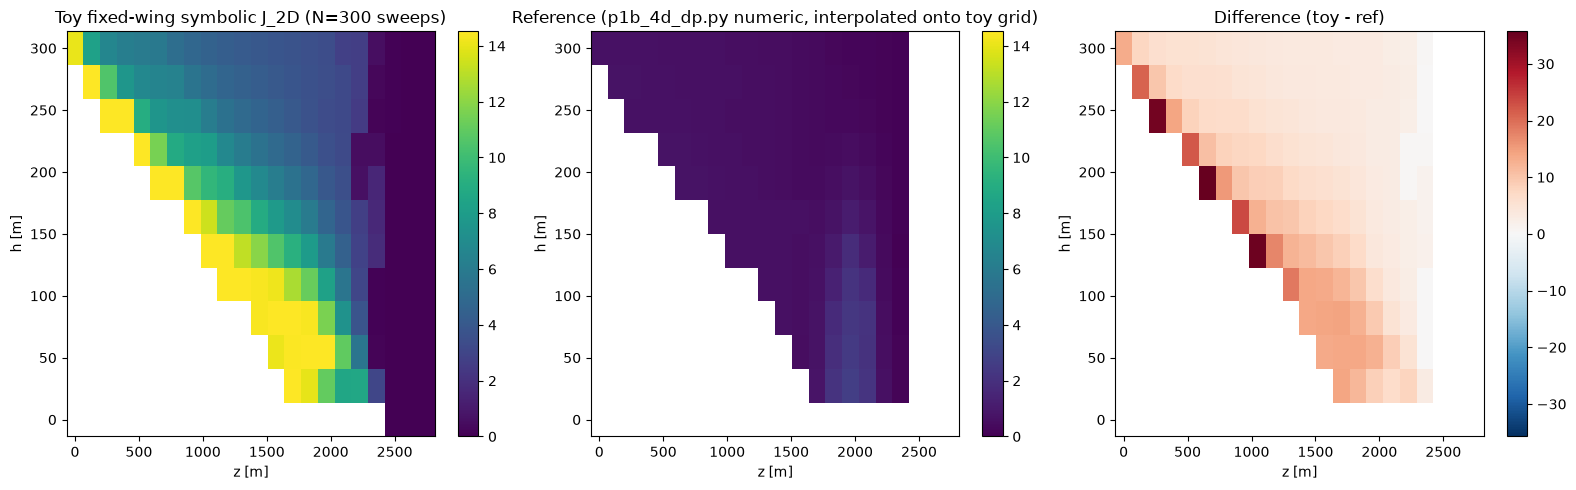

casadi_phase15_validation.png saved


In [19]:
# PHASE 1.5 -- chain sweeps via casadi.Function.mapaccum (NOT a literal
# Python-loop unroll -- that approach crashed with std::bad_alloc at 300
# sweeps because AD through 300 sequentially-duplicated MX graphs blows up
# memory. mapaccum represents the repeated structure compactly and is the
# architecturally correct way to do this; it also fixes the memory issue.
N_SWEEPS4 = 300

J_in_sym = ca.MX.sym('J_in', n_cells4)
zs_in_sym = ca.MX.sym('zs_in', 1)
# bellman_backup4's stage-cost closures were built against the ORIGINAL
# global zsens_sym (not a fresh symbol per call), so the resulting
# expression still depends on that global -- substitute it for zs_in_sym so
# the wrapped Function has no free variables (mapaccum requires this).
J_out_sym_raw = bellman_backup4(J_in_sym, zsens_sym)
J_out_sym = ca.substitute(J_out_sym_raw, zsens_sym, zs_in_sym)
backup_fn4 = ca.Function('backup_fn4', [J_in_sym, zs_in_sym], [J_out_sym])

t0 = time.time()
backup_chain_fn4 = backup_fn4.mapaccum('backup_chain_fn4', N_SWEEPS4)
zs_repeated4 = ca.repmat(zsens_sym, 1, N_SWEEPS4)   # same Z_SENSOR value every sweep
J_all_sweeps4 = backup_chain_fn4(J0_4, zs_repeated4)   # (n_cells4, N_SWEEPS4) -- every intermediate sweep
J_sym4 = J_all_sweeps4[:, -1]
print(f'mapaccum graph built in {time.time()-t0:.1f}s')

J_final_fun4 = ca.Function('J_final_fun4', [zsens_sym], [J_sym4])
t0 = time.time()
J_final_val4 = np.array(J_final_fun4(params['Z_SENSOR'])).ravel()
print(f'evaluated in {time.time()-t0:.1f}s')
n_fin4 = (J_final_val4 < LARGE4).sum()
print(f'after {N_SWEEPS4} sweeps: finite cells: {n_fin4} / {n_cells4}')

# progress check: mapaccum keeps ALL intermediate sweeps, so no need to
# rebuild separate chains per checkpoint -- just slice J_all_sweeps4.
J_all_val4 = np.array(J_final_fun4(params['Z_SENSOR']))  # re-evaluate not needed, but keep simple: use a function returning all sweeps
all_sweeps_fun4 = ca.Function('all_sweeps_fun4', [zsens_sym], [J_all_sweeps4])
J_all_val4 = np.array(all_sweeps_fun4(params['Z_SENSOR']))
for n_check in [10, 30, 60, 120, 180, 240, 300]:
    col = J_all_val4[:, n_check - 1]
    print(f'  N={n_check:4d}: finite cells = {(col < LARGE4).sum()} / {n_cells4}, '
          f'finite max = {col[col < LARGE4].max() if (col < LARGE4).any() else float("nan"):.4f}')

# --- project to 2D: J_2D(z,h) = min_{v,gamma} J_4D(z,h,v,gamma) ---
J4_grid = J_final_val4.reshape(NZ_T2, NH_T2, NV_T2, NG_T2)
J2_toy = np.min(J4_grid, axis=(2, 3))
J2_toy_masked = np.where(J2_toy < LARGE4, J2_toy, np.nan)
print(f'toy J_2D range (finite): [{np.nanmin(J2_toy_masked):.4f}, {np.nanmax(J2_toy_masked):.4f}]')

# --- validate against the numeric fixed-wing reference ---
ref_interp4 = RegularGridInterpolator((z_grid_4ref, h_grid_4ref), J_2D_4ref,
                                       method='linear', bounds_error=False, fill_value=np.nan)
toy_pts2 = np.array([[z, h] for z in z_grid_t2 for h in h_grid_t2])
J_ref_on_toy4 = ref_interp4(toy_pts2).reshape(NZ_T2, NH_T2)

both_fin4 = np.isfinite(J2_toy_masked) & np.isfinite(J_ref_on_toy4)
diff4 = J2_toy_masked[both_fin4] - J_ref_on_toy4[both_fin4]
print(f'cells finite in both: {both_fin4.sum()} / {NZ_T2*NH_T2}')
if both_fin4.sum() > 0:
    print(f'diff (toy - ref): mean={diff4.mean():.4f}, mean|diff|={np.abs(diff4).mean():.4f}, max|diff|={np.abs(diff4).max():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
vmax4 = np.nanpercentile(np.concatenate([J2_toy_masked.ravel(), J_ref_on_toy4.ravel()]), 95)
im0 = axes[0].pcolormesh(z_grid_t2, h_grid_t2, J2_toy_masked.T, cmap='viridis', vmin=0, vmax=vmax4, shading='auto')
axes[0].set_title(f'Toy fixed-wing symbolic J_2D (N={N_SWEEPS4} sweeps)')
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].pcolormesh(z_grid_t2, h_grid_t2, J_ref_on_toy4.T, cmap='viridis', vmin=0, vmax=vmax4, shading='auto')
axes[1].set_title('Reference (p1b_4d_dp.py numeric, interpolated onto toy grid)')
fig.colorbar(im1, ax=axes[1])
diff_grid4 = np.full((NZ_T2, NH_T2), np.nan)
diff_grid4[both_fin4] = diff4
dmax = np.abs(diff4).max() if both_fin4.sum() > 0 else 1.0
im2 = axes[2].pcolormesh(z_grid_t2, h_grid_t2, diff_grid4.T, cmap='RdBu_r', vmin=-dmax, vmax=dmax, shading='auto')
axes[2].set_title('Difference (toy - ref)')
fig.colorbar(im2, ax=axes[2])
for ax in axes:
    ax.set_xlabel('z [m]'); ax.set_ylabel('h [m]')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'casadi_phase15_validation.png'), dpi=120, bbox_inches='tight')
plt.show()
print('casadi_phase15_validation.png saved')


In [20]:
# PHASE 1.5 -- the new thing to validate: AD through the min_{v,gamma}
# PROJECTION step itself, not just through the 4D backup (Phase 1 only
# checked the latter). Cell layout is (iz,ih,iv,ig) with ig fastest, so for
# a fixed (iz,ih) the NV*NG entries are contiguous -- reshape (column-major,
# matches CasADi's convention) into (NV*NG, NZ*NH) and take an elementwise
# min down each column.
NVG_T2 = NV_T2 * NG_T2
NZH_T2 = NZ_T2 * NH_T2

Jmat_sym = ca.reshape(J_sym4, NVG_T2, NZH_T2)
J_2D_proj_sym = Jmat_sym[0, :]
for r in range(1, NVG_T2):
    J_2D_proj_sym = ca.fmin(J_2D_proj_sym, Jmat_sym[r, :])
J_2D_proj_sym = J_2D_proj_sym.T   # (NZH,1)

J_2D_proj_fun = ca.Function('J_2D_proj_fun', [zsens_sym], [J_2D_proj_sym])
J_2D_proj_val = np.array(J_2D_proj_fun(params['Z_SENSOR'])).ravel()

# sanity: symbolic projection must exactly match the post-hoc numpy min from the cell above
sanity_diff = np.abs(J_2D_proj_val.reshape(NZ_T2, NH_T2) - J2_toy).max()
print(f'sanity: symbolic projection vs numpy post-hoc min, max diff = {sanity_diff:.10f} (should be ~0)')

# ca.jacobian on a 1-input/many-output expression defaults to a strategy
# that timed out at 5544x264 scale. Forward-mode (via jtimes with a unit
# seed) costs one pass regardless of output count since there is only ONE
# input (Z_SENSOR is scalar) -- exactly the right mode here.
jac_proj = ca.jtimes(J_2D_proj_sym, zsens_sym, ca.DM(1.0), False)
jac_proj_fun = ca.Function('jac_proj_fun', [zsens_sym], [jac_proj])
grad_ad4 = np.array(jac_proj_fun(params['Z_SENSOR'])).ravel()

EPS4 = 1.0
Jp4 = np.array(J_2D_proj_fun(params['Z_SENSOR'] + EPS4)).ravel()
Jm4 = np.array(J_2D_proj_fun(params['Z_SENSOR'] - EPS4)).ravel()
grad_fd4 = (Jp4 - Jm4) / (2 * EPS4)

reach4 = (J_2D_proj_val < LARGE4)
err4 = grad_ad4[reach4] - grad_fd4[reach4]
print(f'reachable (z,h) cells checked: {reach4.sum()}')
print(f'grad AD range: [{grad_ad4[reach4].min():.6f}, {grad_ad4[reach4].max():.6f}]')
print(f'grad FD range: [{grad_fd4[reach4].min():.6f}, {grad_fd4[reach4].max():.6f}]')
print(f'max |AD - FD|: {np.abs(err4).max():.6e}')
print(f'mean|AD - FD|: {np.abs(err4).mean():.6e}')
n_nz4 = (np.abs(grad_ad4[reach4]) > 1e-8).sum()
print(f'cells with non-negligible d(J_2D_projected)/d(Z_SENSOR): {n_nz4} / {reach4.sum()}')
print('-> this is the key new check: gradient survives the min_{v,gamma} projection, not just the 4D backup.')


sanity: symbolic projection vs numpy post-hoc min, max diff = 0.0000000000 (should be ~0)


reachable (z,h) cells checked: 173
grad AD range: [-0.331395, 0.044282]
grad FD range: [-0.331406, 0.044294]
max |AD - FD|: 6.454505e-04
mean|AD - FD|: 2.370833e-05
cells with non-negligible d(J_2D_projected)/d(Z_SENSOR): 171 / 173
-> this is the key new check: gradient survives the min_{v,gamma} projection, not just the 4D backup.
